# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Andika Bagus Saputra
- **Email:** andikabagus074@gmail.com
- **ID Dicoding:** andikaabgss


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana hubungan antara performa penjual (jumlah penjualan dan nilai transaksi) dengan tingkat kepuasan pelanggan (review score) di setiap wilayah?

- **Pertanyaan 2:** Bagaimana tingkat kepuasan pelanggan terhadap berbagai kategori produk, dan adakah kategori produk dengan tingkat kepuasan rendah yang perlu perhatian?

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install squarify
!pip install folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import squarify
import folium
import branca.colormap as cm

## Data Wrangling

### Gathering Data

In [2]:
customer_df = pd.read_csv('olist_customers_dataset.csv')
geolocation_df = pd.read_csv('olist_geolocation_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv('olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
sellers_df = pd.read_csv('olist_sellers_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')

In [3]:
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [5]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [11]:
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight dari Gathering Data**

Berikut adalah kolom-kolom pada setiap tabel yang dimuat:

**customer_df**
- `customer_id`
- `customer_unique_id`
- `customer_zip_code_prefix`
- `customer_city`
- `customer_state`

**geolocation_df**
- `geolocation_zip_code_prefix`
- `geolocation_lat`
- `geolocation_lng`
- `geolocation_city`
- `geolocation_state`

**order_items_df**
- `order_id`
- `order_item_id`
- `product_id`
- `seller_id`
- `shipping_limit_date`
- `price`
- `freight_value`

**order_payments_df**
- `order_id`
- `payment_sequential`
- `payment_type`
- `payment_installments`
- `payment_value`

**order_reviews_df**
- `review_id`
- `order_id`
- `review_score`
- `review_comment_title`
- `review_comment_message`
- `review_creation_date`
- `review_answer_timestamp`

**orders_df**
- `order_id`
- `customer_id`
- `order_status`
- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

**products_df**
- `product_id`
- `product_category_name`
- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`
- `product_weight_g`
- `product_length_cm`
- `product_height_cm`
- `product_width_cm`

**sellers_df**
- `seller_id`
- `seller_zip_code_prefix`
- `seller_city`
- `seller_state`

**translation_df**
- `product_category_name`
- `product_category_name_english`

### Assessing Data

Tabel Customer

In [12]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [13]:
customer_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [14]:
print('Jumlah duplikasi: ', customer_df.duplicated().sum())

Jumlah duplikasi:  0


In [15]:
customer_df.describe(include='object')

,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


Tabel Geolocation

In [16]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [17]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [18]:
print('Jumlah duplikasi: ', geolocation_df.duplicated().sum())

Jumlah duplikasi:  261831


Tabel Order Items

In [19]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [21]:
print('Jumlah duplikasi: ', order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [22]:
order_items_df.describe(include='float')

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


Tabel Order Payment

In [23]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [24]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [25]:
print('Jumlah duplikasi: ', order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [26]:
order_payments_df[['payment_value']].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [27]:
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


Tabel Order Reviews

In [28]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [29]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [30]:
print('Jumlah duplikasi: ', order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [31]:
order_reviews_df[['review_score']].describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Tabel Orders

In [32]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [33]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [34]:
print('Jumlah duplikasi: ', orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [35]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


Tabel Products

In [36]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [37]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [38]:
print('Jumlah duplikasi: ', products_df.duplicated().sum())

Jumlah duplikasi:  0


In [39]:
translated_products_df = products_df.merge(translation_df, on='product_category_name', how='left')
display(translated_products_df['product_category_name_english'].value_counts())

,count
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
...,...
tablets_printing_image,9
fashion_childrens_clothes,5
home_comfort_2,5


In [40]:
products_df.describe(include='float')

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Tabel Seller

In [41]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [42]:
sellers_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [43]:
print('Jumlah duplikasi: ', sellers_df.duplicated().sum())

Jumlah duplikasi:  0


In [44]:
sellers_df['seller_city'].value_counts()

,count
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
ipua,1
muqui,1
timoteo,1


In [45]:
sellers_df['seller_state'].value_counts()

,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


**Insight dari Assesing Data**
- **customer_df**: Berisi informasi pelanggan. Terdapat 99441 entri, 96096 di antaranya adalah `customer_unique_id` yang unik, menunjukkan beberapa pelanggan memiliki lebih dari satu `customer_id` (mungkin karena beberapa pesanan). Tidak ada nilai yang hilang atau duplikasi baris.
- **geolocation_df**: Berisi data geolokasi berdasarkan kode pos. Terdapat 1000163 entri. Ditemukan 261831 baris duplikat yang perlu ditangani. Tidak ada nilai yang hilang.
- **order_items_df**: Berisi item-item dalam pesanan. Tidak ada nilai yang hilang atau duplikasi baris. Kolom `price` dan `freight_value` memiliki rentang nilai yang bervariasi.
- **order_payments_df**: Berisi informasi pembayaran pesanan. Tidak ada nilai yang hilang atau duplikasi baris. Sebagian besar pembayaran (`76795`) menggunakan `credit_card` dari total 5 jenis pembayaran. Nilai pembayaran bervariasi dari 0 hingga 13664.08.
- **order_reviews_df**: Berisi ulasan pesanan. Terdapat banyak nilai yang hilang pada kolom `review_comment_title` (87656) dan `review_comment_message` (58247). Sebagian besar `review_score` (`50%`) adalah 5, menunjukkan sentimen positif secara umum. Tidak ada duplikasi baris.
- **orders_df**: Berisi informasi umum pesanan. Kolom `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965) memiliki nilai yang hilang. Status pesanan didominasi oleh 'delivered' (`96478`). Tidak ada duplikasi baris.
- **products_df**: Berisi detail produk. Kolom `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty` memiliki 610 nilai yang hilang. Kolom dimensi produk (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`) masing-masing memiliki 2 nilai yang hilang. Setelah digabungkan dengan `translation_df`, 'bed_bath_table' menjadi kategori produk yang paling sering muncul.
- **sellers_df**: Berisi informasi penjual. Tidak ada nilai yang hilang atau duplikasi baris. Penjual paling banyak berlokasi di 'sao paulo' dan 'SP'.

### Cleaning Data

Tabel Customers

In [46]:
#Tabel customers sudah clean

Tabel Geolocation

In [47]:
geolocation_df.drop_duplicates(inplace=True)
print(f'Jumlah duplikasi di geolocation_df setelah dihapus: {geolocation_df.duplicated().sum()}')

Jumlah duplikasi di geolocation_df setelah dihapus: 0


Tabel Orders Item

In [48]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


Tabel Order Payment

In [49]:
# Tabel Order Payment sudah clean

Tabel Order Reviews

In [50]:
#Mengisi missing value
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna('no title')
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna('no comment')

print(f"Jumlah NaN di review_comment_title setelah diisi: {order_reviews_df['review_comment_title'].isna().sum()}")
print(f"Jumlah NaN di review_comment_message setelah diisi: {order_reviews_df['review_comment_message'].isna().sum()}")

Jumlah NaN di review_comment_title setelah diisi: 0
Jumlah NaN di review_comment_message setelah diisi: 0


In [51]:
#Mengubah tipe data date
order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'])
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(order_reviews_df['review_answer_timestamp'])

In [52]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [53]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,no title,no comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,no title,no comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,no title,no comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,no title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,no title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


Tabel Orders

In [54]:
# Mengubah tipe data date
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Mengisi missing value
orders_df['order_approved_at'].fillna(orders_df['order_purchase_timestamp'], inplace=True)
orders_df['order_delivered_carrier_date'].fillna(orders_df['order_estimated_delivery_date'], inplace=True)
orders_df['order_delivered_customer_date'].fillna(orders_df['order_estimated_delivery_date'], inplace=True)

orders_df.info()
print('\nJumlah NaN di orders_df setelah diisi:')
print(orders_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Jumlah NaN di orders_df setelah diisi:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_tim

/tmp/ipykernel_994/265129067.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df['order_approved_at'].fillna(orders_df['order_purchase_timestamp'], inplace=True)
/tmp/ipykernel_994/265129067.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

Tabel Product

In [55]:
# Mengubah kolom kategori dengan bahasa portugis menjadi bahasa inggris
translated_products_df.drop(columns=['product_category_name'], inplace=True)
translated_products_df.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)

# Mengisi missing value data kategorik
translated_products_df['product_category_name'] = translated_products_df['product_category_name'].fillna('unknown category')

# Mengisi missing value data numerik dengan median
numerical_cols_to_fill = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numerical_cols_to_fill:
    median_val = translated_products_df[col].median()
    translated_products_df[col] = translated_products_df[col].fillna(median_val)

print('Jumlah NaN di products_df setelah cleaning dan translasi:')
print(translated_products_df.isna().sum())

Jumlah NaN di products_df setelah cleaning dan translasi:
product_id                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
product_category_name         0
dtype: int64


In [56]:
translated_products_df['product_category_name'].head()

,product_category_name
0,perfumery
1,art
2,sports_leisure
3,baby
4,housewares


Tabel Sellers

In [57]:
# Tabel seller sudah clean

**Insight dari Cleaning Data**

- **customer_df**: Tidak ada cleaning yang diperlukan karena data sudah bersih dari missing value dan duplikasi.
- **geolocation_df**: Baris-baris duplikat berhasil dihapus.

- **order_items_df**: Kolom `shipping_limit_date` diubah menjadi tipe data datetime.

- **order_payments_df**: Tidak ada cleaning yang diperlukan karena data sudah bersih dari missing value dan duplikasi.

- **order_reviews_df**: Missing value pada `review_comment_title` dan `review_comment_message` telah diisi dengan 'no title' dan 'no comment', memastikan tidak ada data ulasan yang kosong. Kolom tanggal (`review_creation_date`, `review_answer_timestamp`) juga telah diubah menjadi tipe data datetime.

- **orders_df**: Semua kolom tanggal berhasil diubah menjadi tipe data datetime. Missing value pada `order_approved_at` diisi dengan `order_purchase_timestamp`, dan missing value pada tanggal pengiriman (`order_delivered_carrier_date`, `order_delivered_customer_date`) diisi dengan `order_estimated_delivery_date`, memastikan kelengkapan data terkait proses pesanan.

- **products_df**: `product_category_name` telah berhasil diterjemahkan ke bahasa Inggris dan missing value diisi dengan 'unknown category'. Missing value pada kolom dimensi produk (panjang, lebar, tinggi, berat, dll.) juga telah diisi dengan nilai median, memastikan kelengkapan data produk.

- **sellers_df**: Tidak ada cleaning yang diperlukan karena data sudah bersih dari missing value dan duplikasi.

## Exploratory Data Analysis (EDA)

Tabel Customers

In [58]:
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [59]:
# Banyak customer berdasarkan State
customer_by_state = customer_df.groupby('customer_state').agg({
    'customer_id': 'count'
}).sort_values(by='customer_id', ascending=False)

customer_by_state.head()

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045


In [60]:
# Banyak customer berdasarkan City
customer_by_city = customer_df.groupby('customer_city').agg({
    'customer_id': 'count'
}).sort_values(by='customer_id', ascending=False)

customer_by_city.head()

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521


**Insight EDA Tabel Customers:**
- **Jumlah Pelanggan Unik:** Terdapat 99441 `customer_id` yang berbeda, tetapi hanya 96096 `customer_unique_id`. Ini menunjukkan bahwa beberapa pelanggan telah melakukan pembelian lebih dari satu kali, mengindikasikan adanya pelanggan setia atau berulang.
- **Distribusi Pelanggan Berdasarkan Negara Bagian:** Mayoritas pelanggan berasal dari negara bagian SP (Sao Paulo), diikuti oleh RJ (Rio de Janeiro) dan MG (Minas Gerais). Ini menunjukkan bahwa kegiatan e-commerce paling terkonsentrasi di wilayah-wilayah ini.
- **Distribusi Pelanggan Berdasarkan Kota:** Sao Paulo adalah kota dengan jumlah pelanggan terbanyak, yang konsisten dengan dominasi negara bagian SP. Kota-kota besar lainnya seperti Rio de Janeiro dan Belo Horizonte juga memiliki jumlah pelanggan yang signifikan.

Tabel Order Items

In [61]:
print("Statistika Deskriptif untuk Price(Harga) dan Freight Value(Ongkir):")
round(order_items_df[['price', 'freight_value']].describe(),3)

Statistika Deskriptif untuk Price(Harga) dan Freight Value(Ongkir):


,price,freight_value
count,112650.000,112650.000
mean,120.654,19.990
std,183.634,15.806
min,0.850,0.000
25%,39.900,13.080
50%,74.990,16.260
75%,134.900,21.150
max,6735.000,409.680


In [62]:
print("\nBanyak order_item_id (items per order):")
order_items_df['order_item_id'].value_counts()


Banyak order_item_id (items per order):


,count
order_item_id,
1,98666
2,9803
3,2287
4,965
5,460
6,256
7,58
8,36
9,28


In [63]:
# Menambah kolom revenue
order_items_df['revenue'] = order_items_df['price'] + order_items_df['freight_value']
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [64]:
order_items_df['revenue'].describe()

,revenue
count,112650.000000
mean,140.644059
std,190.724394
min,6.080000
25%,55.220000
50%,92.320000
75%,157.937500
max,6929.310000


In [65]:
# Revenue berdasarkan Category
merged_items_products = pd.merge(order_items_df, translated_products_df, on='product_id', how='left')
revenue_by_category = merged_items_products.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False)

revenue_by_category.head()

,revenue
product_category_name,
health_beauty,1441248.07
watches_gifts,1305541.61
bed_bath_table,1241681.72
sports_leisure,1156656.48
computers_accessories,1059272.40


**Insight EDA Tabel Order Items:**
- **Distribusi Harga dan Biaya Pengiriman:** Harga produk bervariasi dari BRL 0.85 hingga BRL 6735 , dengan rata-rata sekitar BRL 120.65 BRL. Biaya pengiriman berkisar dari 0 hingga BRL 409.68, dengan rata-rata BRL 19.99. Ini menunjukkan adanya variasi yang signifikan dalam nilai produk dan biaya logistik.
- **Jumlah Item per Pesanan:** Sebagian besar pesanan (98666 dari 112650) hanya berisi satu item (`order_item_id = 1`), menunjukkan bahwa pembelian multi-item dalam satu pesanan tidak terlalu umum.
- **revenue (Produk + Pengiriman):** Kolom `revenue` yang baru ditambahkan menunjukkan nilai total transaksi, dengan rata-rata BRL 140.64 dan nilai maksimum mencapai BRL 6929.31.
- **revenue Berdasarkan Kategori Produk:** Kategori 'health_beauty' memiliki revenue penjualan tertinggi (BRL 1.441.248,07), diikuti oleh 'watches_gifts' dan 'bed_bath_table'. Ini mengindikasikan bahwa kategori-kategori ini adalah kontributor terbesar terhadap pendapatan.

Tabel Order Payment

In [66]:
# Banyak jenis pembayaran yang digunakan untuk transaksi
payment_by_type = order_payments_df['payment_type'].value_counts()

payment_by_type.head()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [67]:
# Jumlah nilai pembayaran berdasarkan tipe pembayaran
payment_by_value = order_payments_df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

payment_by_value.head()

,payment_value
payment_type,
credit_card,12542084.19
boleto,2869361.27
voucher,379436.87
debit_card,217989.79
not_defined,0.00


**Insight EDA Tabel Order Payments:**
- **Distribusi Jenis Pembayaran:** Sebagian besar pembayaran dilakukan menggunakan 'credit_card' (76795 transaksi), diikuti oleh 'boleto' (19784 transaksi), dan 'voucher' (5775 transaksi). Ada juga sejumlah kecil pembayaran menggunakan 'debit_card' (1529 transaksi) dan 'not_defined' (3 transaksi). Ini menunjukkan dominasi kartu kredit sebagai metode pembayaran pilihan.
- **Nilai Pembayaran berdasarkan Jenis Pembayaran:** Credit card juga mendominasi total nilai pembayaran (±12,5 juta), jauh di atas boleto (±2,8 juta), sedangkan metode lain berkontribusi sangat kecil.

Tabel Order Reviews

In [68]:
order_reviews_df.merge(orders_df,on = 'order_id')[['order_id','review_score']]

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5
...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,5
99220,22ec9f0669f784db00fa86d035cf8602,5
99221,55d4004744368f5571d1f590031933e4,5
99222,7725825d039fc1f0ceb7635e3f7d9206,4


In [69]:
# Rata-rata skor review berdasarkan kategori produk
merged_reviews_items = pd.merge(order_reviews_df, order_items_df, on='order_id', how='left')
merged_reviews_products = pd.merge(merged_reviews_items, translated_products_df, on='product_id', how='left')

average_review_score_by_category = merged_reviews_products.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)
average_review_score_by_category

,review_score
product_category_name,
cds_dvds_musicals,4.642857
fashion_childrens_clothes,4.500000
books_general_interest,4.446266
costruction_tools_tools,4.444444
flowers,4.419355
...,...
fashion_male_clothing,3.641221
home_comfort_2,3.629630
office_furniture,3.493183


**Insight EDA Tabel Order Reviews:**
- **Missing Values pada Komentar:** Terdapat banyak missing value pada kolom `review_comment_title` dan `review_comment_message`. Ini menunjukkan bahwa banyak pelanggan memberikan skor ulasan tanpa menyertakan judul atau detail komentar tertulis. Hal ini telah ditangani dengan mengisi nilai-nilai yang hilang dengan 'no title' dan 'no comment' untuk menjaga kelengkapan data.
- **Distribusi Skor Ulasan:** Sebagian besar ulasan memiliki skor 5 (50%), yang mengindikasikan tingkat kepuasan pelanggan yang tinggi secara keseluruhan. Skor rata-rata secara keseluruhan juga menunjukkan sentimen positif.
- **Rata-rata Skor Ulasan Berdasarkan Kategori Produk:** Kategori produk seperti 'cds_dvds_musicals', 'fashion_childrens_clothes', dan 'books_general_interest' memiliki rata-rata skor ulasan yang tinggi, menunjukkan kepuasan yang kuat di area tersebut. Sebaliknya, kategori seperti 'security_and_services', 'diapers_and_hygiene', dan 'office_furniture' memiliki rata-rata skor ulasan yang lebih rendah, yang mungkin memerlukan perhatian lebih lanjut untuk meningkatkan kepuasan pelanggan.

Tabel Order

In [70]:
# Persentase Status Order
order_stats = round(orders_df['order_status'].value_counts()/len(orders_df) * 100,3)
order_stats

,count
order_status,
delivered,97.020
shipped,1.113
canceled,0.629
unavailable,0.612
invoiced,0.316
processing,0.303
created,0.005
approved,0.002


In [71]:
# waktu approval
orders_df['approval_time'] = (
    orders_df['order_approved_at'] - orders_df['order_purchase_timestamp']
).dt.total_seconds() / 3600  # jam

# waktu ke kurir
orders_df['processing_time'] = (
    orders_df['order_delivered_carrier_date'] - orders_df['order_approved_at']
).dt.days

# waktu pengiriman
orders_df['shipping_time'] = (
    orders_df['order_delivered_customer_date'] - orders_df['order_delivered_carrier_date']
).dt.days

# total delivery time
orders_df['total_delivery_time'] = (
    orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']
).dt.days

orders_df[['approval_time', 'processing_time', 'shipping_time', 'total_delivery_time']].head()

,approval_time,processing_time,shipping_time,total_delivery_time
0,0.178333,2,6,8
1,30.713889,0,12,13
2,0.276111,0,9,9
3,0.298056,3,9,13
4,1.030556,0,1,2


In [72]:
print("Rata-rata approval time (jam):", orders_df['approval_time'].mean())
print("Rata-rata processing time (hari):", orders_df['processing_time'].mean())
print("Rata-rata shipping time (hari):", orders_df['shipping_time'].mean())
print("Rata-rata total delivery time (hari):", orders_df['total_delivery_time'].mean())

Rata-rata approval time (jam): 10.402330038805813
Rata-rata processing time (hari): 2.679588901961967
Rata-rata shipping time (hari): 8.863476835510504
Rata-rata total delivery time (hari): 12.460152251083557


**Insight EDA Tabel Orders:**
- **Distribusi Status Pesanan:** Mayoritas pesanan (sekitar 97.02%) berstatus 'delivered', menunjukkan efisiensi dalam penyelesaian pesanan. Status lain seperti 'shipped', 'canceled', dan 'unavailable' memiliki persentase yang jauh lebih kecil.
- **Waktu Persetujuan Pesanan (Approval Time):** Rata-rata waktu persetujuan pesanan adalah sekitar 10.40 jam, menunjukkan proses persetujuan yang relatif cepat setelah pembelian.
- **Waktu Pemrosesan Pesanan (Processing Time):** Rata-rata waktu yang dibutuhkan untuk memproses pesanan hingga diserahkan ke kurir adalah sekitar 2.68 hari.
- **Waktu Pengiriman (Shipping Time):** Rata-rata waktu pengiriman oleh kurir hingga sampai ke pelanggan adalah sekitar 8.86 hari.
- **Total Waktu Pengiriman (Total Delivery Time):** Secara keseluruhan, rata-rata waktu yang dibutuhkan dari pembelian hingga pesanan diterima oleh pelanggan adalah sekitar 12.46 hari.

Tabel Products

In [73]:
# Distribusi Produk Kategori
total_sales_by_category = translated_products_df['product_category_name'].value_counts()
total_sales_by_category.head()


,count
product_category_name,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335


In [74]:
# Menambahkan kolom volume = Lenght x Width x Height
translated_products_df['volume'] = translated_products_df['product_length_cm'] * translated_products_df['product_width_cm'] * translated_products_df['product_height_cm']
display(translated_products_df['volume'].head(10))

# Korelasi Volume dan Berat
correlation_volume_weight = translated_products_df['volume'].corr(translated_products_df['product_weight_g'])
print("\nKorelasi antara Volume dan Berat:", correlation_volume_weight)

,volume
0,2240.0
1,10800.0
2,2430.0
3,2704.0
4,4420.0
5,2090.0
6,73920.0
7,12800.0
8,5967.0
9,2040.0



Korelasi antara Volume dan Berat: 0.8030064901896733


In [75]:
translated_products_df.describe(include=['int', 'float'])

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume
count,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
mean,48.523656,768.227945,2.166975,2276.376802,30.814725,16.937422,23.196534,16563.485843
std,10.156155,629.658469,1.728063,4281.926387,16.914005,13.637175,12.078707,27056.334089
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,168.000000
25%,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000,2880.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,6840.000000
75%,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,18480.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,296208.000000


**Insight EDA Tabel Products:**
- **Distribusi Kategori Produk:** Kategori produk 'bed_bath_table' memiliki jumlah produk terbanyak (3029), diikuti oleh 'sports_leisure' (2867) dan 'furniture_decor' (2657). Ini menunjukkan bahwa produk-produk dari kategori tersebut adalah yang paling banyak tersedia atau sering diperdagangkan di platform.
- **Korelasi Volume dan Berat:** Terdapat korelasi yang kuat antara volume dan berat produk (0.803). Ini menunjukkan bahwa produk dengan volume yang lebih besar cenderung memiliki berat yang lebih tinggi, yang merupakan hal yang wajar dan dapat berguna dalam estimasi biaya pengiriman.


**Insight dari Statistika Deskriptif Kolom Numerik pada Tabel Products:**
-   `product_photos_qty`: Jumlah foto produk berkisar dari **1 hingga 20**, dengan rata-rata sekitar **2.17 foto** per produk. Ini menunjukkan bahwa sebagian besar produk memiliki sedikit foto.
-   `product_weight_g`: Berat produk memiliki rentang yang sangat luas, dari **0g hingga 40425g**, dengan rata-rata sekitar **2276g**. Nilai minimum 0g mungkin merupakan entri data yang salah atau produk virtual.
-   `product_length_cm`, `product_height_cm`, `product_width_cm`: Dimensi produk juga menunjukkan variasi yang besar, mencerminkan beragamnya ukuran produk yang dijual.
-   `volume`: Kolom `volume` yang dihitung (`product_length_cm * product_width_cm * product_height_cm`) berkisar dari **168 hingga 296208 cm³**, dengan rata-rata sekitar **16563 cm³**. Variasi ini menegaskan keragaman ukuran fisik produk.


Tabel Sellers

In [76]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [77]:
seller_by_state = sellers_df['seller_state'].value_counts()
seller_by_state.head()

,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171


In [78]:
seller_by_city = sellers_df['seller_city'].value_counts()
seller_by_city.head()

,count
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52


In [79]:
# Merge tabel order_items dan sellers
merged_sales_sellers = pd.merge(order_items_df, sellers_df, on='seller_id', how='left')

# Merge tabel products dan sellers
merged_sales_sellers_products = pd.merge(merged_sales_sellers, translated_products_df, on='product_id', how='left')

# Distribusi revenue seller berdasarkan negara bagian
total_sales_by_seller_state = merged_sales_sellers_products.groupby('seller_state')['revenue'].sum().sort_values(ascending=False)
total_sales_by_seller_state.head(10)

,revenue
seller_state,
SP,10235883.88
PR,1458900.73
MG,1224159.80
RJ,937814.12
SC,738973.13
RS,435802.63
BA,305262.24
DF,116243.54
PE,103886.31


In [80]:
# Distribusi revenue berdasarkan kota
total_sales_by_seller_city = merged_sales_sellers_products.groupby('seller_city')['revenue'].sum().sort_values(ascending=False)
total_sales_by_seller_city.head(10)

,revenue
seller_city,
sao paulo,3181746.13
ibitinga,762274.01
curitiba,541875.84
rio de janeiro,404637.88
guarulhos,376782.25
ribeirao preto,314682.17
itaquaquecetuba,290945.23
santo andre,274810.78
belo horizonte,254228.11


In [81]:
revenue_by_seller_id = merged_sales_sellers_products.groupby('seller_id')['revenue'].sum().sort_values(ascending=False)
display(revenue_by_seller_id.head(10))

,revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
7c67e1448b00f6e969d365cea6b010ab,239536.44
53243585a1d6dc2643021fd1853d8905,235856.68
4a3ca9315b744ce9f8e9374361493884,235539.96
fa1c13f2614d7b5c4749cbc52fecda94,204084.73
da8622b14eb17ae2831f4ac5b9dab84a,185192.32
7e93a43ef30c4f03f38b393420bc753a,182754.05
1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
7a67c85e85bb2ce8582c35f2203ad736,162648.38


**Insight EDA Tabel Sellers**

-   **Distribusi Penjual Berdasarkan Negara Bagian:**
    -   Mayoritas penjual berasal dari negara bagian **SP (São Paulo)** dengan 1849 penjual.
    -   Diikuti oleh **PR (Paraná)** dengan 349 penjual, dan **MG (Minas Gerais)** dengan 244 penjual.
    -   Ini menunjukkan bahwa sebagian besar operasi penjualan terkonsentrasi di wilayah São Paulo, yang konsisten dengan distribusi pelanggan.

-   **Distribusi Penjual Berdasarkan Kota:**
    -   Kota **sao paulo** memiliki jumlah penjual terbanyak dengan 694 penjual.
    -   Diikuti oleh **curitiba** dengan 127 penjual, dan **rio de janeiro** dengan 96 penjual.
    -   Sama halnya dengan negara bagian, kota São Paulo adalah pusat aktivitas penjualan yang dominan.

- **Distribusi revenue Berdasarkan Negara Bagian**
  - Distribusi penjualan menunjukkan konsentrasi yang sangat tinggi pada wilayah tertentu. Pada tingkat state, São Paulo (SP) mendominasi dengan revenue sekitar 10.235.883, jauh di atas PR (1.458.901), MG (1.224.159), dan RJ (937.814).
- **Distribusi revenue Berdasarkan Kota**
  - Kota São Paulo kembali menjadi kontributor terbesar dengan 3.181.746, diikuti Ibitinga (762.274), Curitiba (541.876), dan Rio de Janeiro (404.638).
  - Pola ini menunjukkan distribusi Pareto, di mana sebagian kecil wilayah menyumbang mayoritas penjualan, sekaligus membuka peluang ekspansi di wilayah dengan kontribusi lebih rendah.

- **Distribusi revenue Berdasarkan Seller_id**
  - `selled_id` dengan id '4869f7a5dfa277a7dca6462dcf3b52b2' memperoleh revenue tertinggi dengan penjualan sebesar BRL 249640.70

## Visualization & Explanatory Analysis

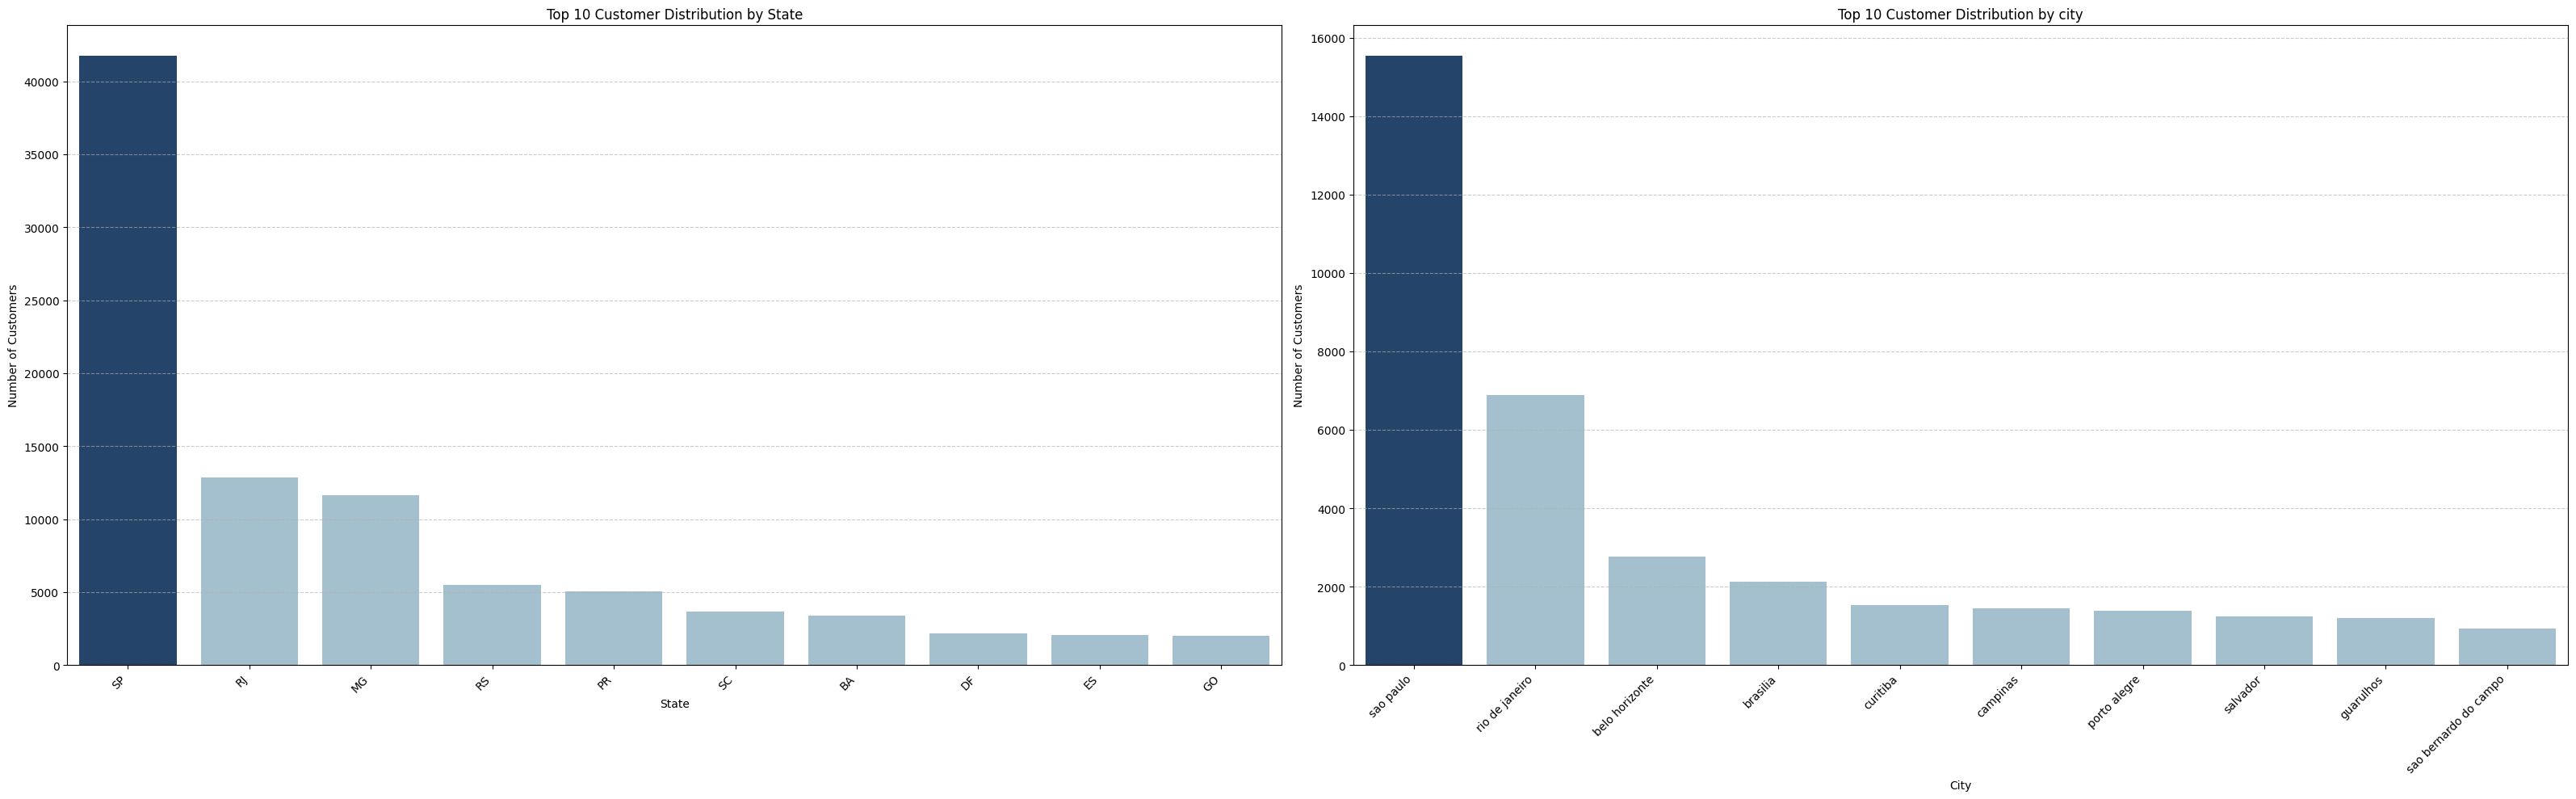

In [82]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))
colors0 = ["#184375", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5", "#9dc2d5"]

# Plot distribusi customer berdasarkan state
sns.barplot(x=customer_by_state.head(10).index, y=customer_by_state['customer_id'].head(10), palette = colors0, hue=customer_by_state.head(10).index, legend=False, ax=ax[0])
ax[0].set_title('Top 10 Customer Distribution by State')
ax[0].set_xlabel('State')
ax[0].set_ylabel('Number of Customers')
ax[0].set_xticks(ticks=range(len(customer_by_state.head(10).index)), labels=customer_by_state.head(10).index, rotation=45, ha='right')
ax[0].grid(axis='y', linestyle='--', alpha=0.65)

# Plot distribusi customer berdasarkan City
sns.barplot(x=customer_by_city.head(10).index, y=customer_by_city['customer_id'].head(10), palette = colors0, hue=customer_by_state.head(10).index, legend=False, ax=ax[1])
ax[1].set_title('Top 10 Customer Distribution by city')
ax[1].set_xlabel('City')
ax[1].set_ylabel('Number of Customers')
ax[1].set_xticks(ticks=range(len(customer_by_city.head(10).index)), labels=customer_by_city.head(10).index, rotation=45, ha='right')
ax[1].grid(axis='y', linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

Berdasarkan kedua plot batang di atas, data menunjukkan adanya dominasi geografis yang sangat timpang, di mana Negara Bagian São Paulo (SP) mendominasi dengan jumlah mencapai lebih dari 40.000 orang. Angka ini jauh melampaui gabungan beberapa negara bagian besar di bawahnya seperti Rio de Janeiro (RJ) dan Minas Gerais (MG), yang masing-masing hanya berada di kisaran 11.000 hingga 13.000 pelanggan. Dominasi ini pun tercermin pada skala kota, di mana Kota São Paulo memimpin dengan lebih dari 15.000 pelanggan, hampir dua kali lipat dibandingkan Kota Rio de Janeiro yang menempati posisi kedua.

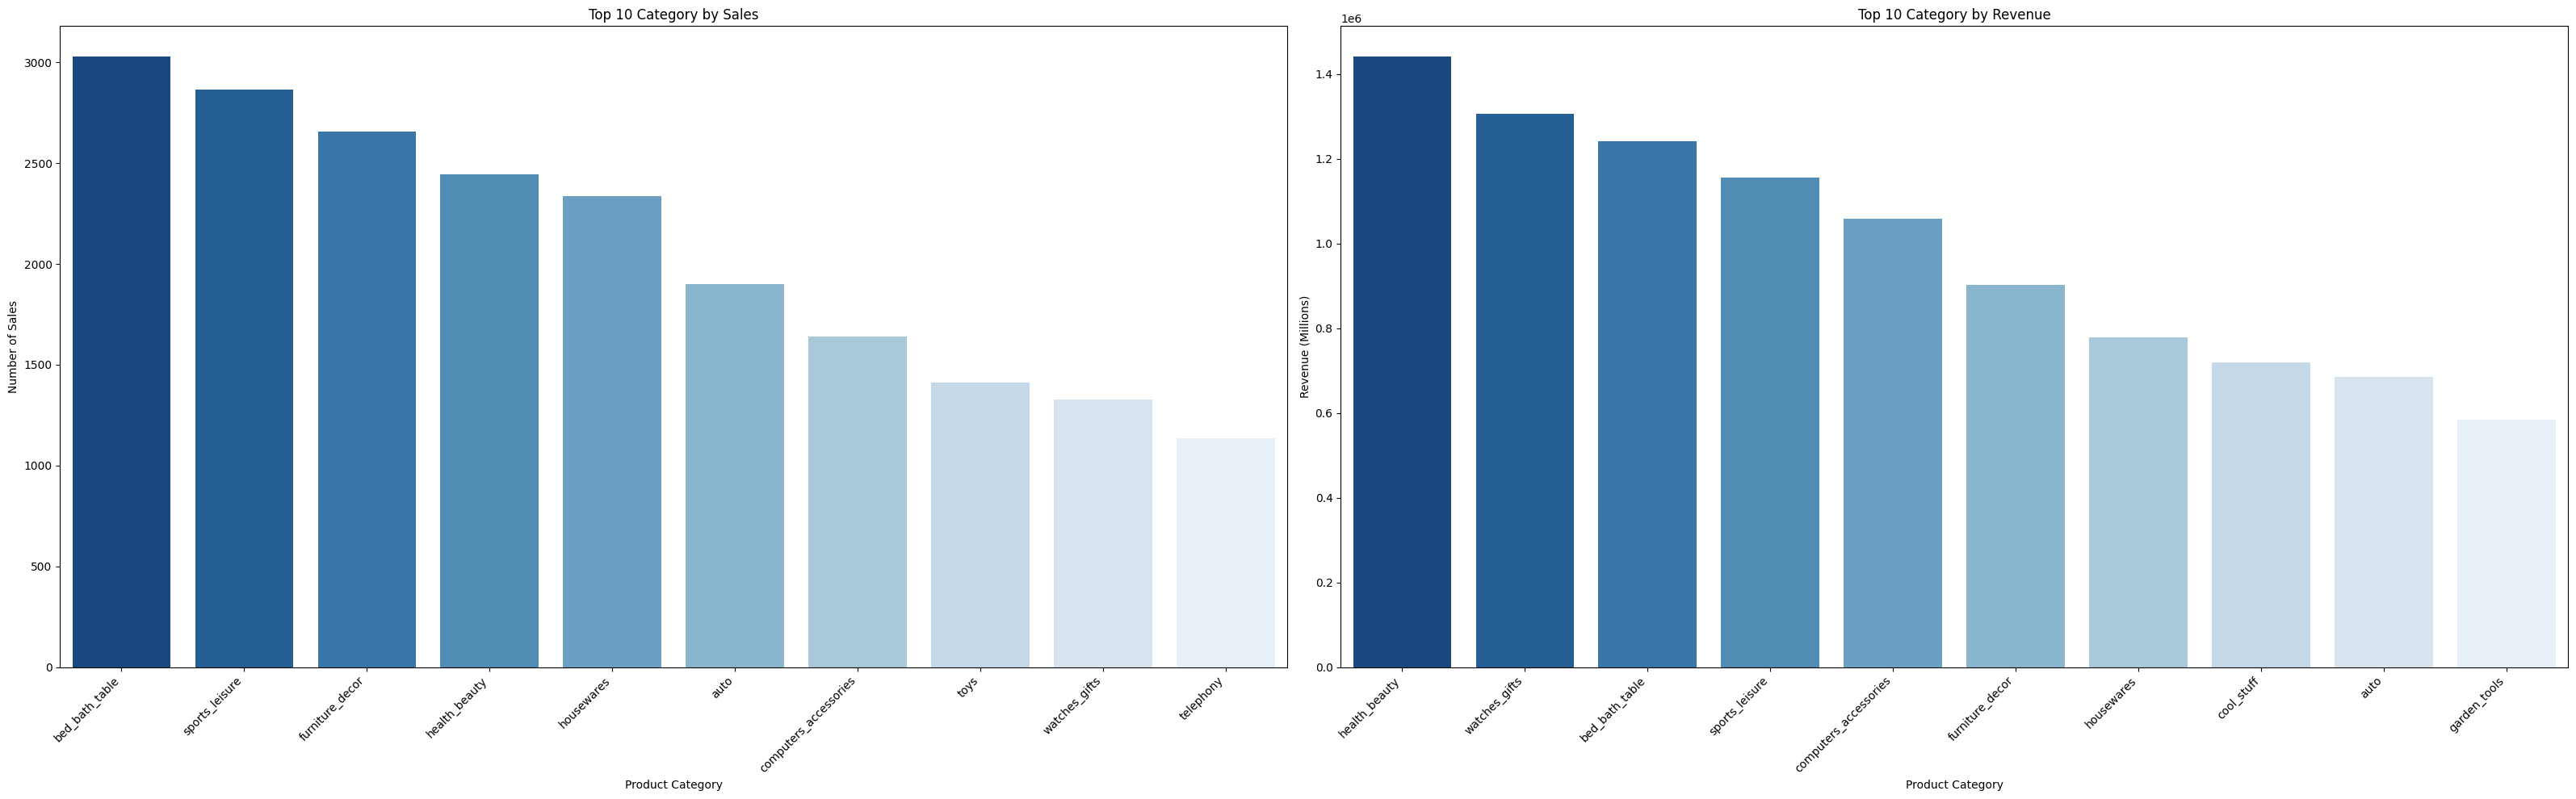

In [101]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))
colors = sns.color_palette("Blues", n_colors = 10)

# Distribusi Total Penjualan berdasarkan kategori produk
sns.barplot(x=total_sales_by_category.head(10).index, y=total_sales_by_category.head(10), palette = colors, hue=total_sales_by_category.head(10), legend = False, ax=ax[0])
ax[0].set_title('Top 10 Category by Sales')
ax[0].set_xlabel('Product Category')
ax[0].set_ylabel('Number of Sales')
ax[0].set_xticks(ticks=range(len(total_sales_by_category.head(10).index)), labels=total_sales_by_category.head(10).index, rotation=45, ha='right')

# Distribusi revenue berdasarkan kategori produk
sns.barplot(x=revenue_by_category.head(10).index, y=revenue_by_category.head(10), palette = colors, hue=revenue_by_category.head(10), legend = False, ax=ax[1])
ax[1].set_title('Top 10 Category by Revenue')
ax[1].set_xlabel('Product Category')
ax[1].set_ylabel('Revenue (Millions)')
ax[1].set_xticks(ticks=range(len(revenue_by_category.head(10).index)), labels=revenue_by_category.head(10).index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

Analisis terhadap data penjualan menunjukkan adanya perbedaan karakteristik yang kontras antara kategori produk yang paling banyak terjual secara kuantitas dengan kategori yang menyumbang pendapatan terbesar. Pada grafik *Top 10 Category by Sales*, kategori `bed_bath_table` menempati posisi puncak dengan volume penjualan lebih dari 3.000 unit, diikuti oleh `sports_leisure` dan `furniture_decor`.

Di sisi lain, grafik *Top 10 Category by Revenue* menyajikan perspektif yang berbeda, di mana kategori `health_beauty` memimpin sebagai penyumbang pendapatan terbesar mencapai lebih dari 1,4 juta. Menariknya, kategori `watches_gifts` yang tidak masuk dalam lima besar secara volume penjualan justru melesat ke posisi kedua dalam hal pendapatan. Fenomena ini menunjukkan adanya nilai jual rata-rata yang jauh lebih tinggi pada produk jam tangan dan kecantikan dibandingkan perlengkapan rumah tangga

/tmp/ipykernel_994/1917148230.py:4: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(x=payment_by_type, y=payment_by_type.index, palette=colors0, hue=payment_by_type.index, legend=False, ax=ax[0])
/tmp/ipykernel_994/1917148230.py:11: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(x=payment_by_value, y=payment_by_value.index, palette=colors0, hue=payment_by_value.index, legend=False, ax=ax[1])


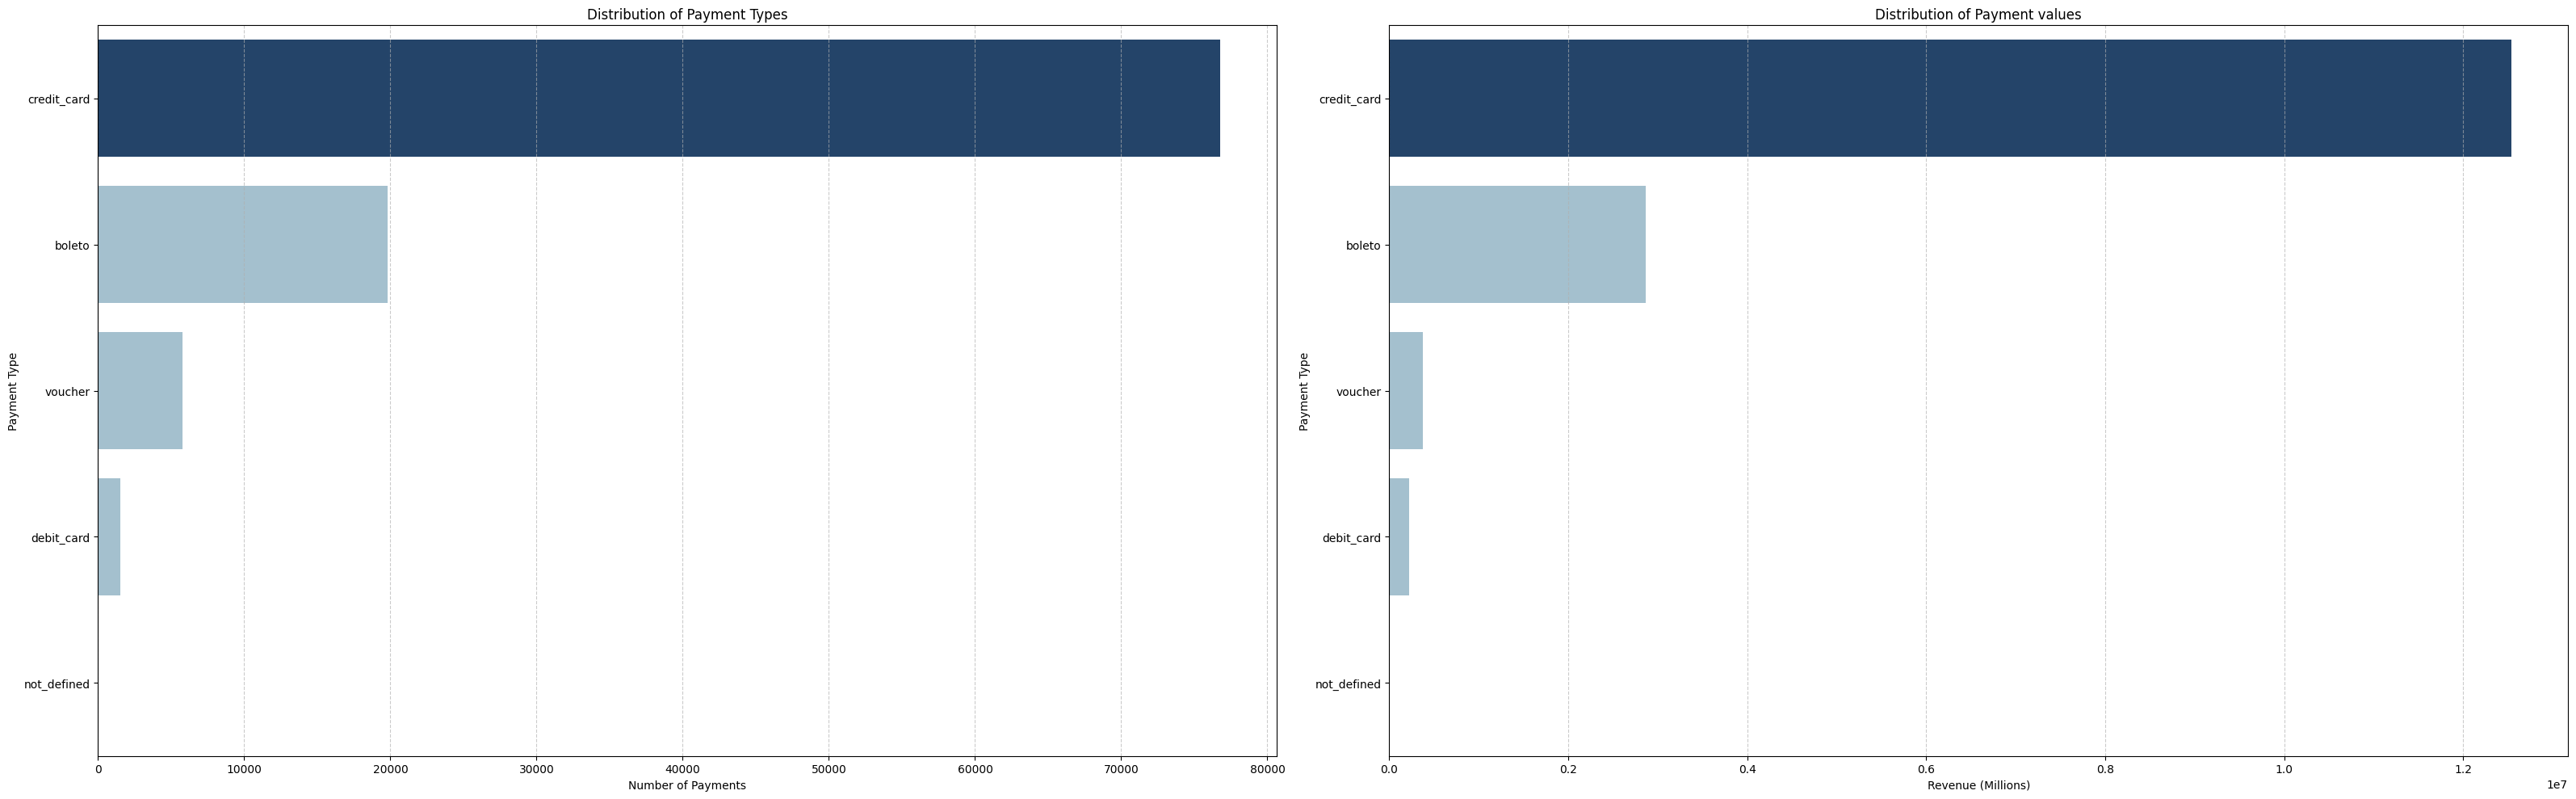

In [84]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))

# Distribusi jenis pembayaran yang digunakan
sns.barplot(x=payment_by_type, y=payment_by_type.index, palette=colors0, hue=payment_by_type.index, legend=False, ax=ax[0])
ax[0].set_title('Distribution of Payment Types')
ax[0].set_xlabel('Number of Payments')
ax[0].set_ylabel('Payment Type')
ax[0].grid(axis='x', linestyle='--', alpha=0.65)

# Distribusi revenue berdasarkan jenis pembayaran
sns.barplot(x=payment_by_value, y=payment_by_value.index, palette=colors0, hue=payment_by_value.index, legend=False, ax=ax[1])
ax[1].set_title('Distribution of Payment values')
ax[1].set_xlabel('Revenue (Millions)')
ax[1].set_ylabel('Payment Type')
ax[1].grid(axis='x', linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

Secara keseluruhan, bisnis ini sangat bergantung pada ekosistem kartu kredit. Dominasi yang sangat timpang ini mengindikasikan bahwa fitur-fitur pendukung kartu kredit (seperti kemudahan *checkout* satu klik atau program cicilan) adalah pendorong utama penjualan. Metode "not_defined" yang hampir tidak terlihat menunjukkan bahwa sistem pencatatan data pembayaran sudah sangat rapi, karena hampir tidak ada transaksi yang gagal dikategorikan.

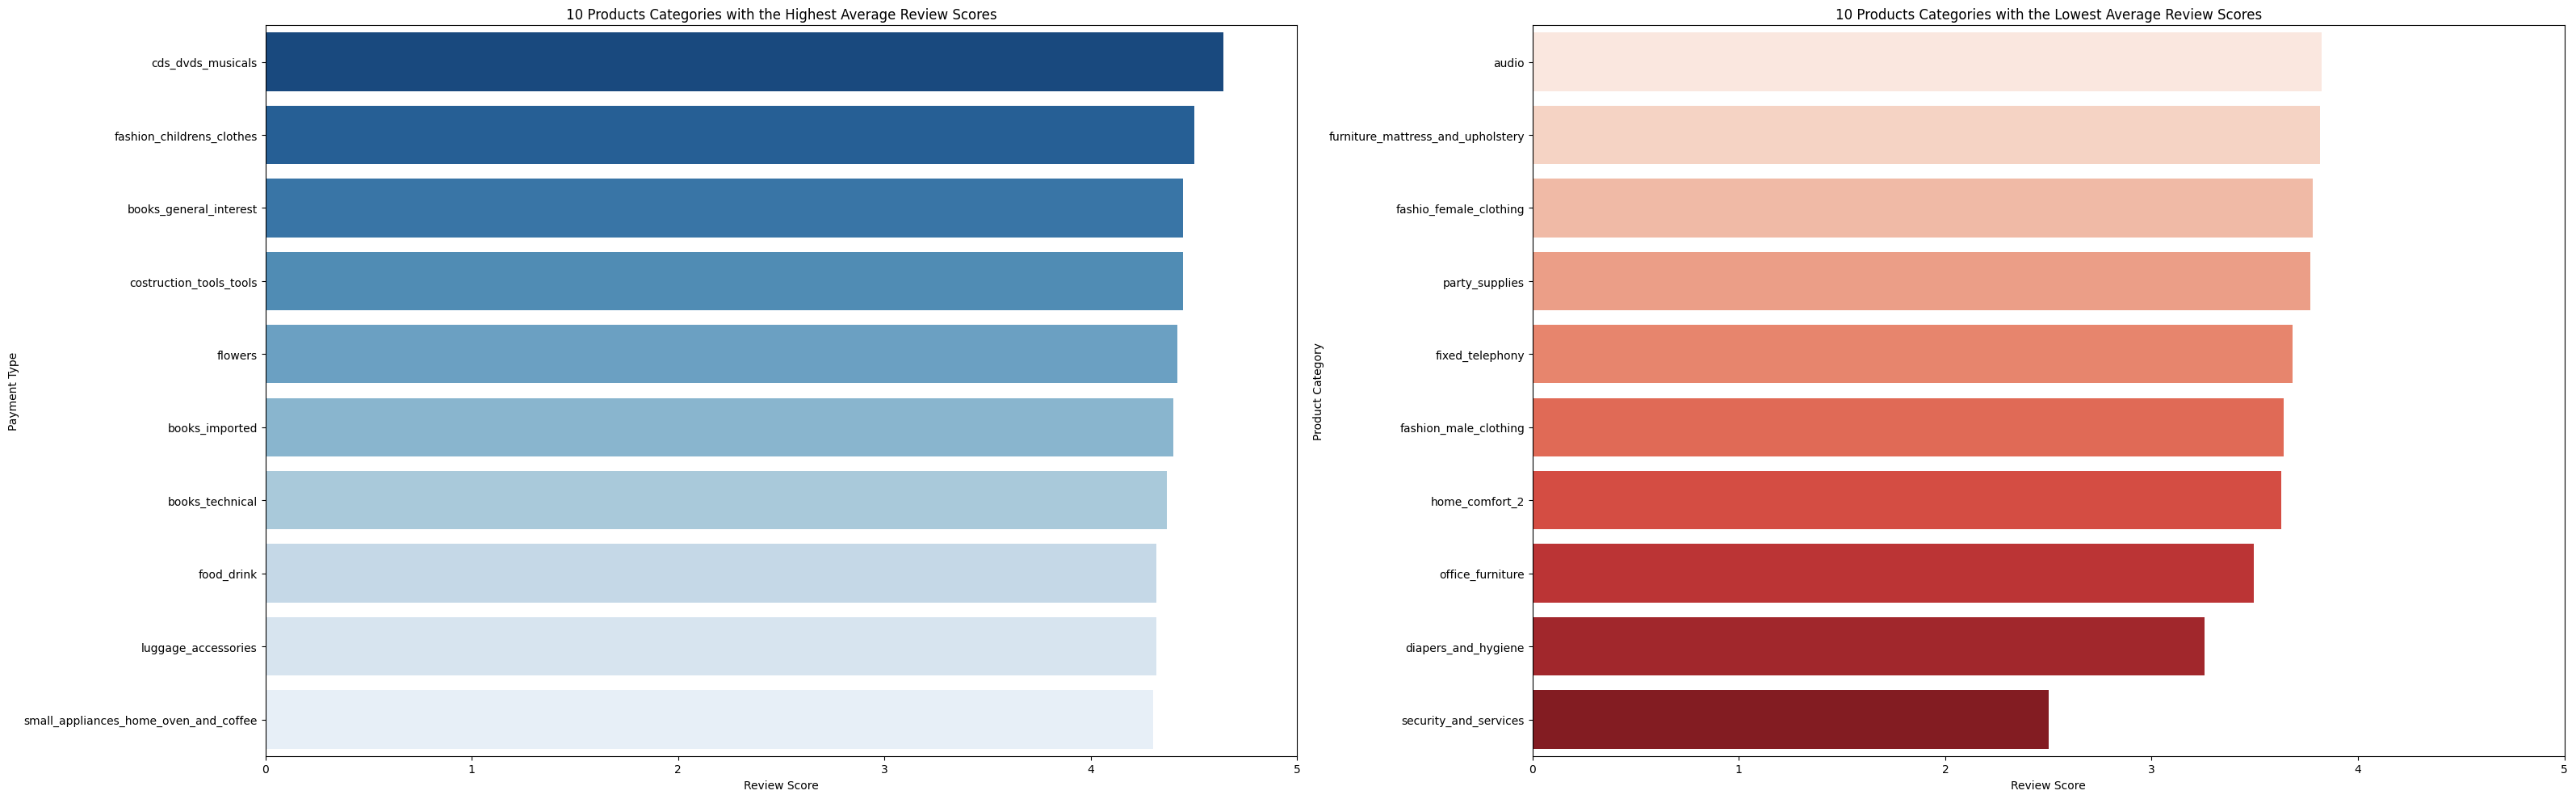

In [100]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))

# Kategori produk dengan rata-rata rating tertinggi
sns.barplot(x=average_review_score_by_category.head(10), y=average_review_score_by_category.head(10).index, palette=(colors), hue=average_review_score_by_category.head(10), legend=False, ax=ax[0])
ax[0].set_title('10 Products Categories with the Highest Average Review Scores')
ax[0].set_xlabel('Review Score')
ax[0].set_ylabel('Payment Type')
ax[0].set_xlim(0, 5)

# Kategori produk dengan rata-rata rating terendah
sns.barplot(x=average_review_score_by_category.tail(10), y=average_review_score_by_category.tail(10).index, palette='Reds', hue=average_review_score_by_category.tail(10).index, legend=False, ax=ax[1])
ax[1].set_title('10 Products Categories with the Lowest Average Review Scores')
ax[1].set_xlabel('Review Score')
ax[1].set_ylabel('Product Category')
ax[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

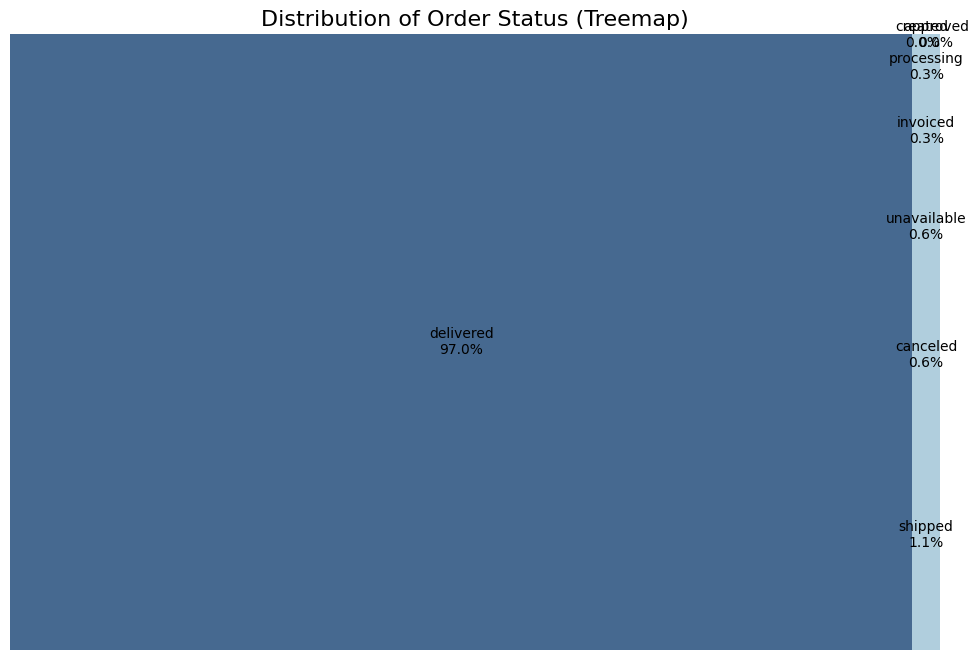

In [86]:
# Distribusi Status Order sebagai Treemap
plt.figure(figsize=(12, 8))
order_status_df = order_stats.reset_index()
order_status_df.columns = ['order_status', 'count']

# Label
order_status_df['percentage'] = (order_status_df['count'] / order_status_df['count'].sum()) * 100
labels = [f"{row['order_status']}\n{row['percentage']:.1f}%" for index, row in order_status_df.iterrows()]

squarify.plot(sizes=order_status_df['count'],
              label=labels,
              alpha=.8,
              color=sns.color_palette(colors0))

plt.title('Distribution of Order Status (Treemap)', fontsize=16)
plt.axis('off')
plt.show()

Visualisasi distribusi status pesanan menunjukkan tingkat keberhasilan operasional yang sangat tinggi, di mana 97.0% dari total pesanan berada pada status "delivered" (terkirim). Dominasi kotak biru tua yang memenuhi hampir seluruh area treemap ini mengindikasikan bahwa rantai pasok dan sistem logistik perusahaan berfungsi dengan sangat efektif dalam menyelesaikan transaksi hingga ke tangan pelanggan. Angka keberhasilan yang nyaris sempurna ini merupakan indikator kuat bahwa perusahaan memiliki tingkat *order fulfillment* yang sehat dan kepercayaan pelanggan yang terjaga.

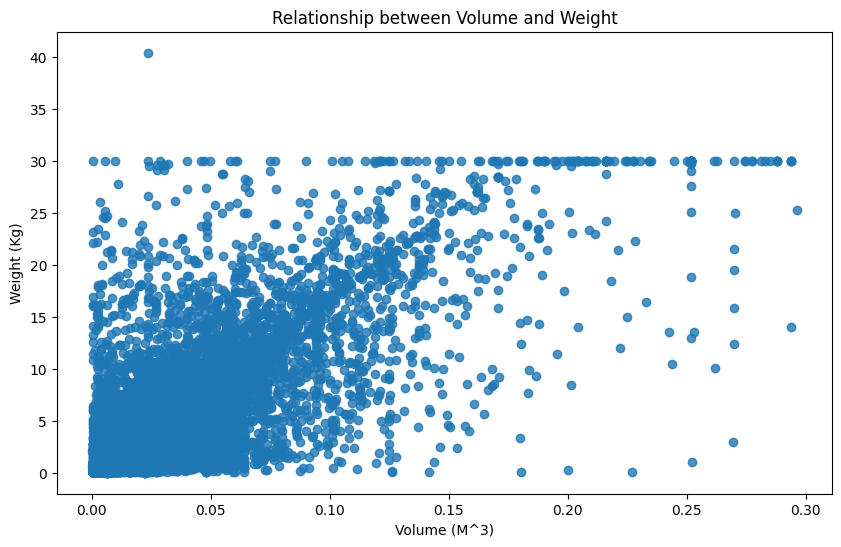


Korelasi antara Volume dan Berat: 0.8030064901896733


In [87]:
# Hubungan antara volume product dan berat product
plt.figure(figsize=(10, 6))
plt.scatter(x = translated_products_df['volume']/1e6, y= translated_products_df['product_weight_g']/1000, alpha=0.8)
plt.xlabel('Volume (M^3)')
plt.ylabel('Weight (Kg)')
plt.title('Relationship between Volume and Weight')
plt.show()

correlation_volume_weight = translated_products_df['volume'].corr(translated_products_df['product_weight_g'])
print("\nKorelasi antara Volume dan Berat:", correlation_volume_weight)

Data ini sangat penting untuk perhitungan ongkos kirim. Karena korelasi yang kuat sebesar 0,80, perusahaan dapat memprediksi berat barang berdasarkan volumenya (atau sebaliknya) dengan akurasi yang cukup baik. Namun, adanya batasan di angka 30 Kg menyarankan agar perusahaan meninjau kembali kebijakan pengiriman untuk barang-barang yang sangat berat guna menghindari kesalahan estimasi biaya atau kendala logistik di lapangan.

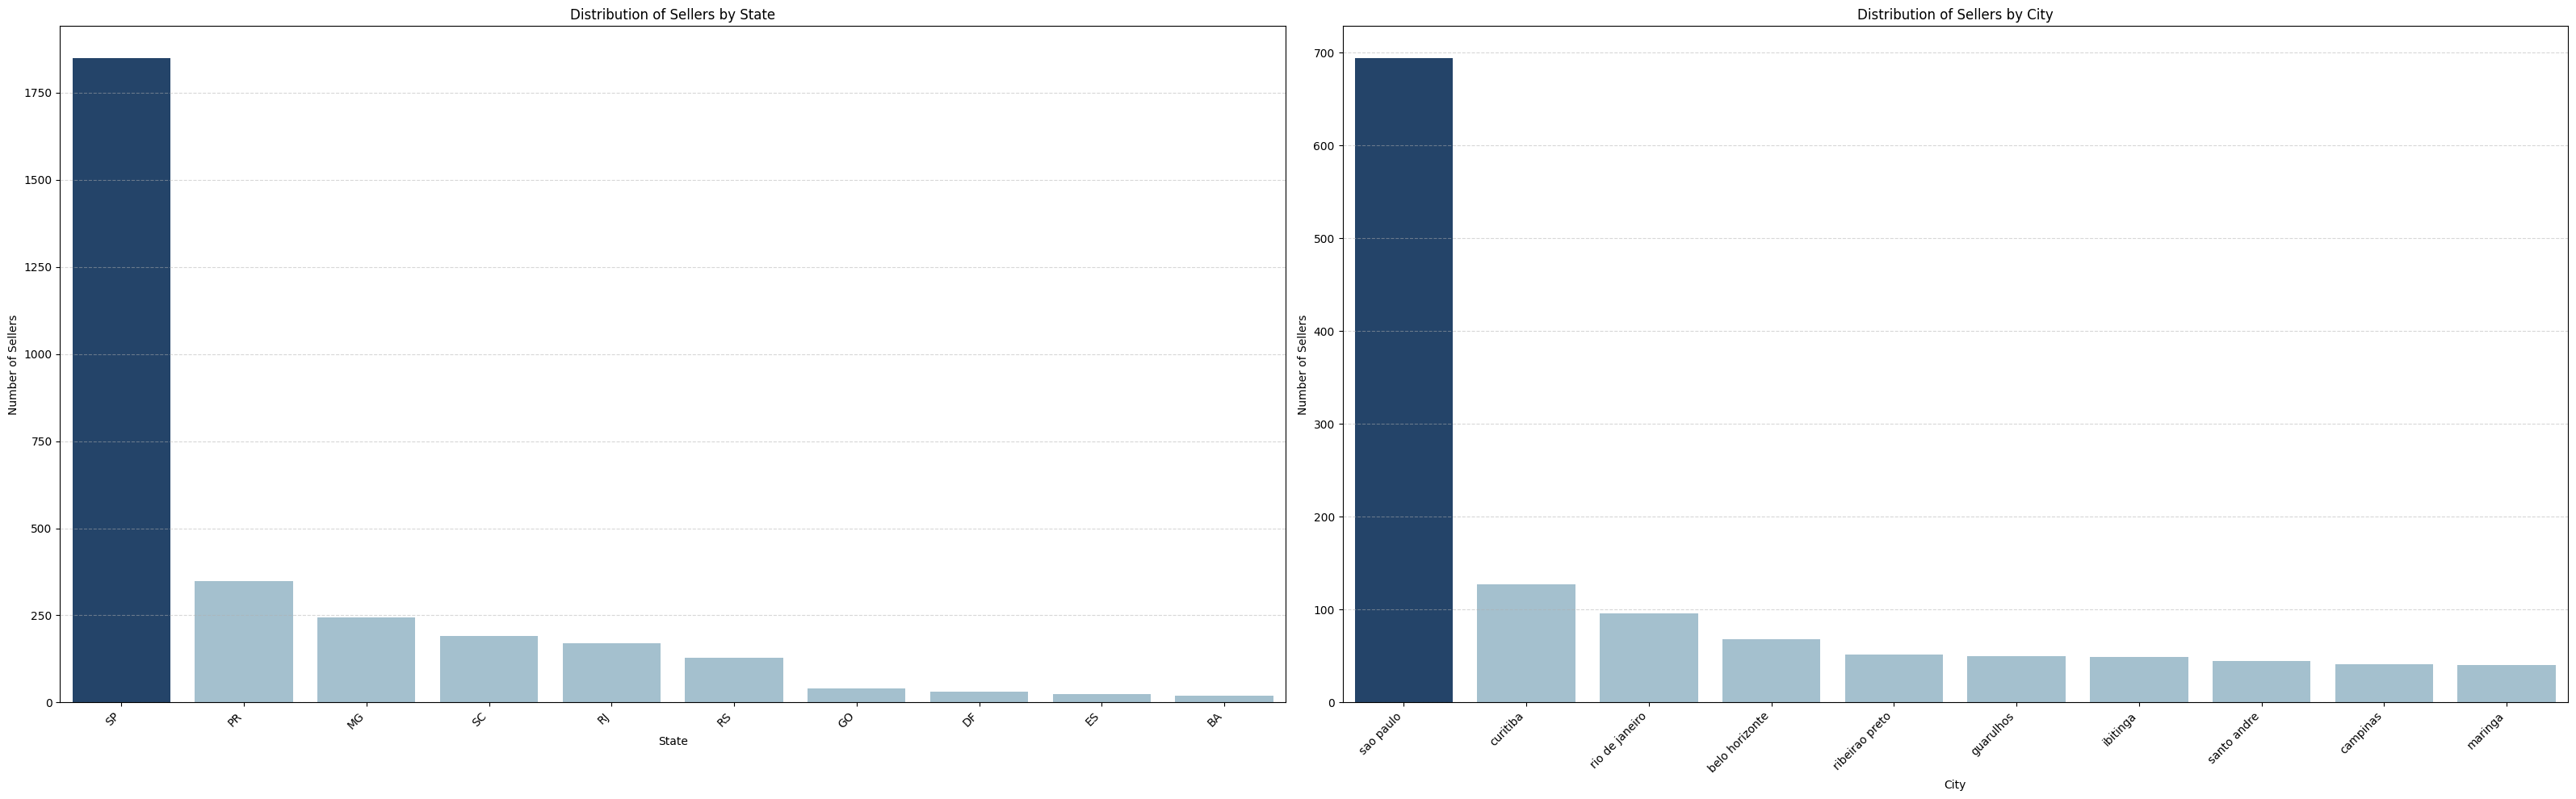

In [88]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))

# Distribusi Seller berdasarkan State
sns.barplot(y=seller_by_state.head(10), x=seller_by_state.head(10).index, palette=colors0, hue=seller_by_state.head(10).index, legend=False, ax=ax[0])
ax[0].set_title('Distribution of Sellers by State')
ax[0].set_ylabel('Number of Sellers')
ax[0].set_xlabel('State')
ax[0].set_xticks(ticks=range(len(seller_by_state.head(10).index)), labels=seller_by_state.head(10).index, rotation=45, ha='right')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Distribusi Seller berdasarkan City
sns.barplot(y=seller_by_city.head(10), x=seller_by_city.head(10).index, palette=colors0, hue=seller_by_city.head(10).index, legend=False, ax=ax[1])
ax[1].set_title('Distribution of Sellers by City')
ax[1].set_ylabel('Number of Sellers')
ax[1].set_xlabel('City')
ax[1].set_xticks(ticks=range(len(seller_by_city.head(10).index)), labels=seller_by_city.head(10).index, rotation=45, ha='right')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Negara bagian SP memiliki lebih dari 1.750 penjual, yang berkali-kali lipat dibandingkan peringkat kedua, yaitu Paraná (PR) dengan sekitar 350 penjual. Kota São Paulo sendiri menampung hampir 700 penjual, mengonfirmasi bahwa kota ini adalah pusat ekonomi dan distribusi utama dalam ekosistem bisnis Anda.

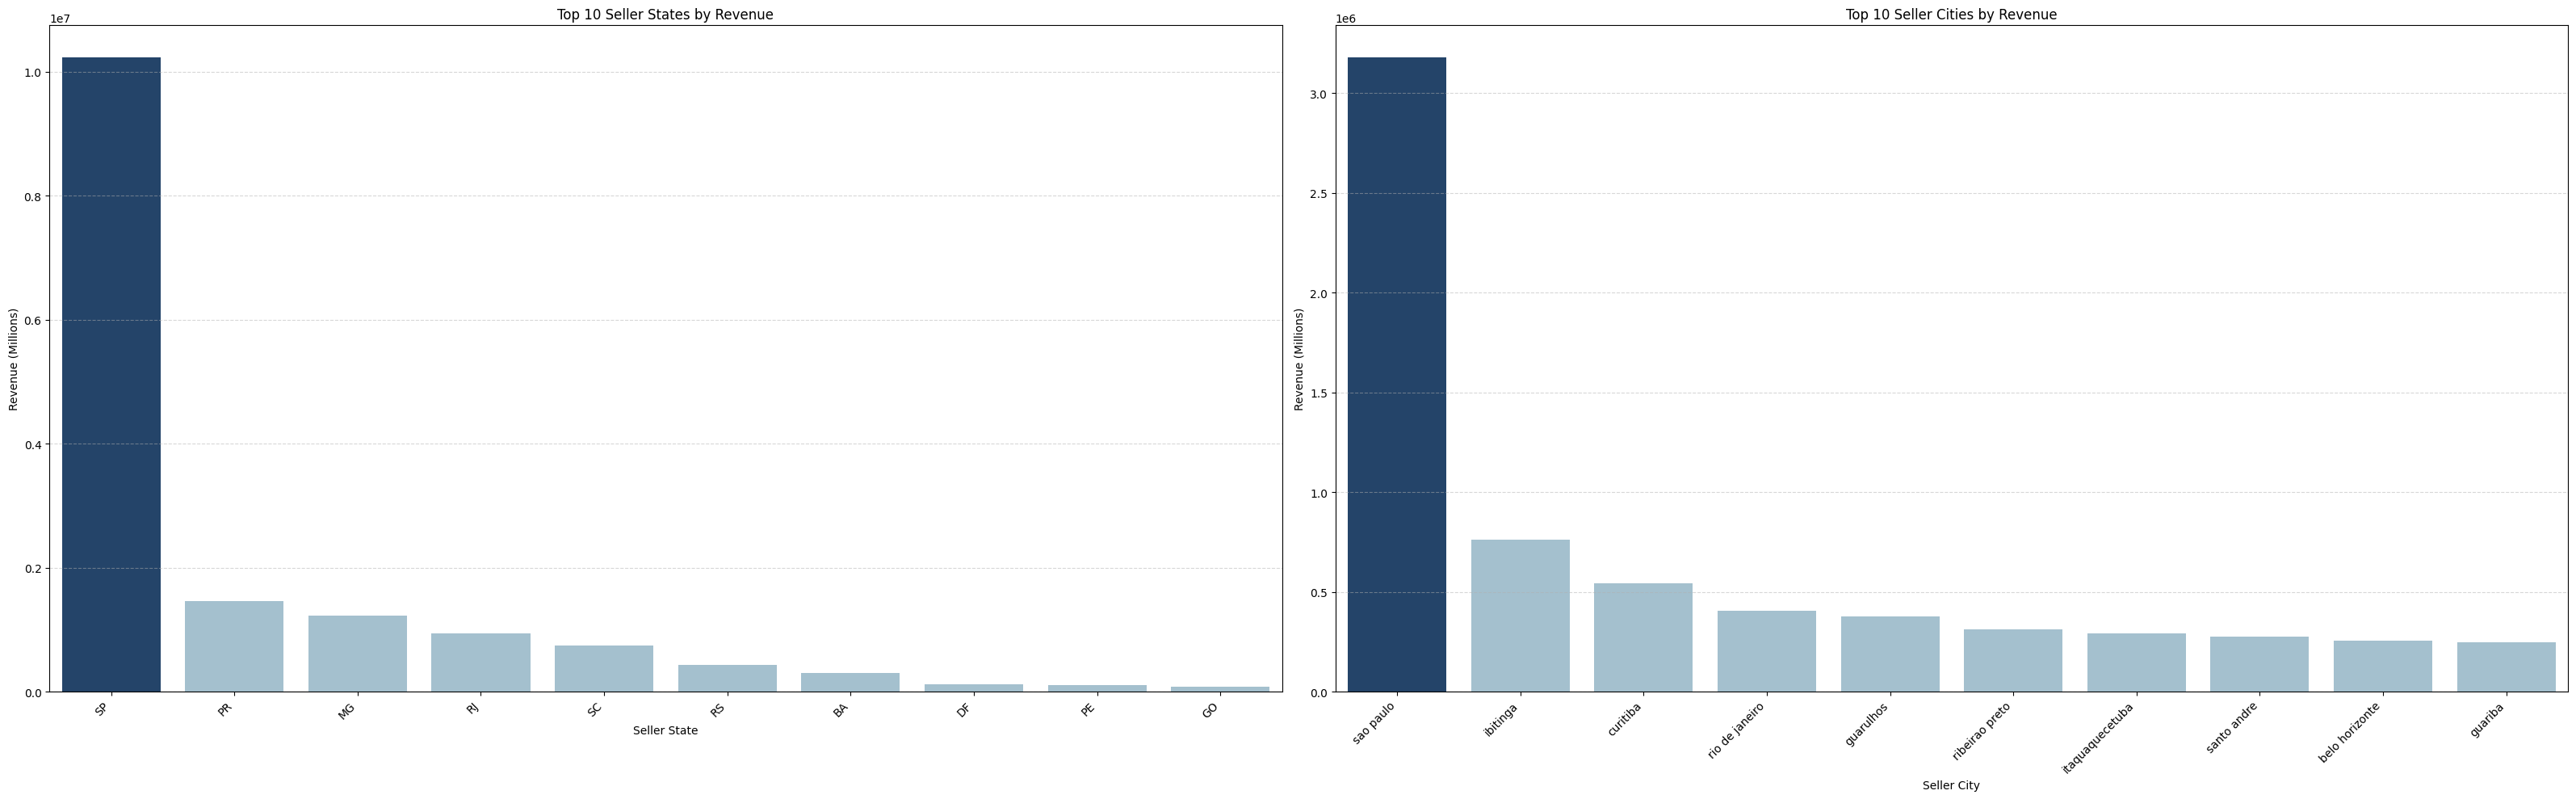

In [89]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))

# Distribusi revenue seller berdasarkan negara bagian
sns.barplot(x=total_sales_by_seller_state.head(10).index, y=total_sales_by_seller_state.head(10), palette=colors0[:10], hue=total_sales_by_seller_state.head(10).index, legend=False, ax=ax[0])
ax[0].set_title('Top 10 Seller States by Revenue')
ax[0].set_xlabel('Seller State')
ax[0].set_ylabel('Revenue (Millions)')
ax[0].set_xticks(ticks=range(len(total_sales_by_seller_state.head(10).index)), labels=total_sales_by_seller_state.head(10).index, rotation=45, ha='right')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Distribusi revenue seller berdasarkan kota
sns.barplot(x=total_sales_by_seller_city.head(10).index, y=total_sales_by_seller_city.head(10), palette=colors0[:10], hue=total_sales_by_seller_city.head(10).index, legend=False, ax=ax[1])
ax[1].set_title('Top 10 Seller Cities by Revenue')
ax[1].set_xlabel('Seller City')
ax[1].set_ylabel('Revenue (Millions)')
ax[1].set_xticks(ticks=range(len(total_sales_by_seller_city.head(10).index)), labels=total_sales_by_seller_city.head(10).index, rotation=45, ha='right')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Negara Bagian SP mencatat pendapatan lebih dari 10 juta BRL, yang hampir 10 kali lipat lebih besar dibandingkan peringkat kedua (PR).

Di tingkat kota, Sao Paulo menyumbang pendapatan di atas 3 juta BRL. Menariknya, kota Ibitinga berada di posisi kedua, mengungguli kota-kota besar lain seperti Rio de Janeiro, yang mengindikasikan Ibitinga sebagai hub penjual yang sangat produktif meskipun bukan ibu kota negara bagian.

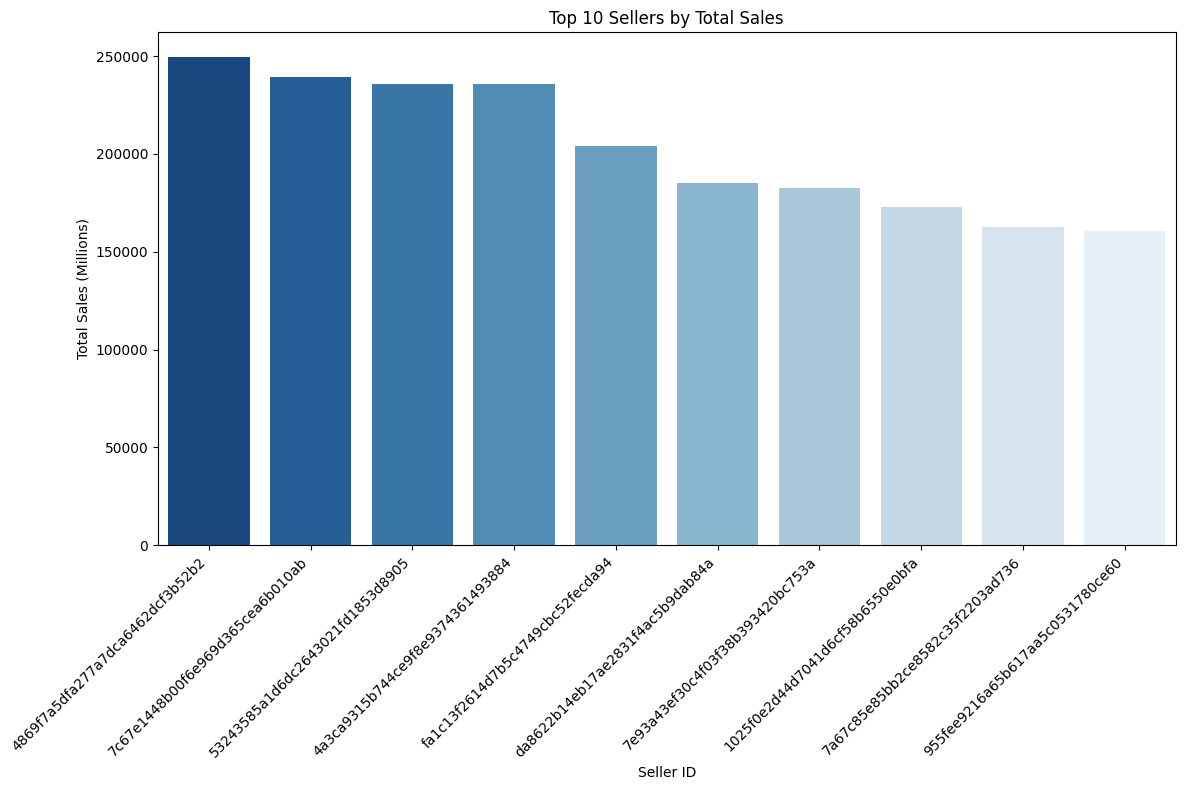

In [99]:
# Top 10 Seller by Revenue
plt.figure(figsize=(12, 8))
sns.barplot(x=revenue_by_seller_id.head(10).index, y=revenue_by_seller_id.head(10), palette=colors, hue=revenue_by_seller_id.head(10), legend=False)
plt.title('Top 10 Sellers by Total Sales')
plt.xlabel('Seller ID')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dari sisi distribusi penjualan, pendapatan perusahaan sangat bergantung pada sekelompok kecil "penjual elit". Sepuluh penjual teratas, yang dipimpin oleh ID "4869f7a..." yang mampu mencatatkan angka penjualan di kisaran 150.000 hingga 250.000 (Millions). Keberhasilan para penjual top ini menjadi penopang utama kesehatan finansial platform secara keseluruhan.

### Pertanyaan 1:
Bagaimana tingkat kepuasan pelanggan terhadap berbagai kategori produk, dan adakah kategori produk dengan tingkat kepuasan rendah yang perlu perhatian?

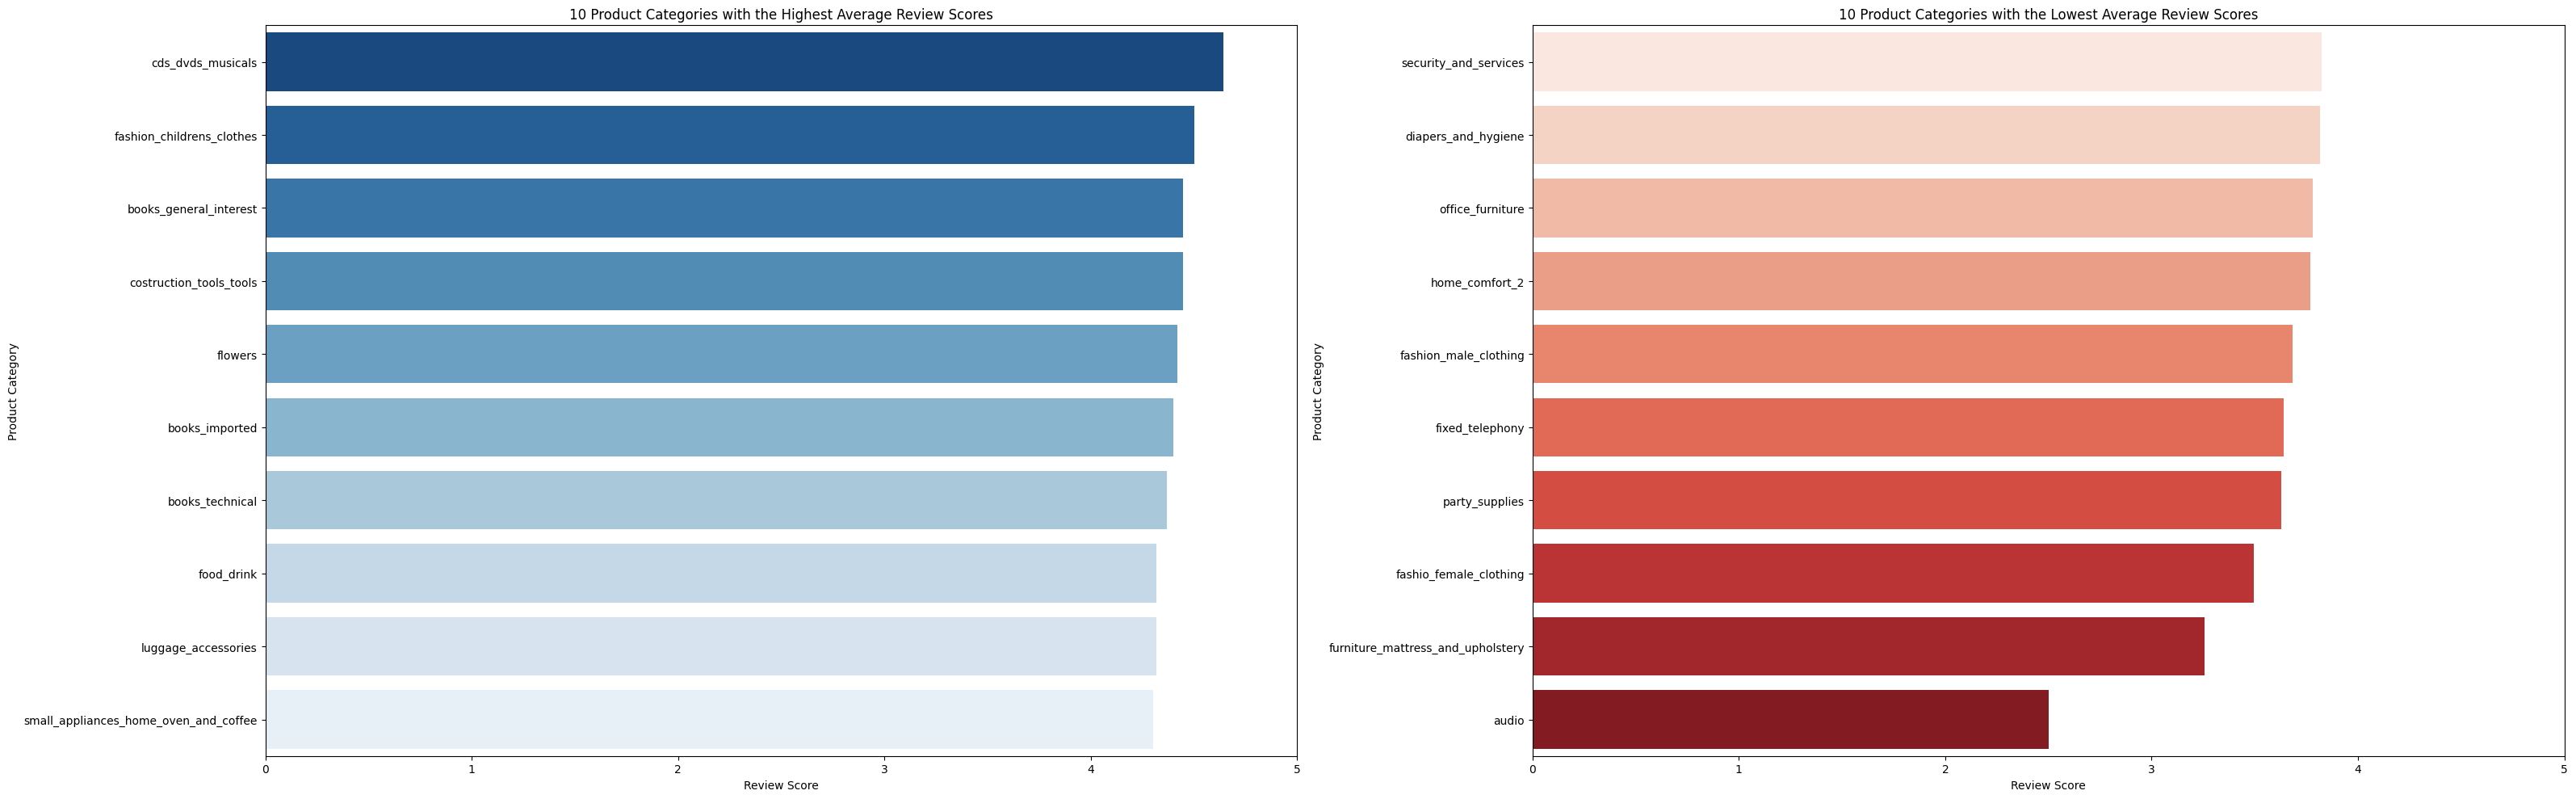

In [98]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 10))

# Kategori produk dengan rata-rata rating tertinggi
sns.barplot(x=average_review_score_by_category.head(10), y=average_review_score_by_category.head(10).index, palette=list(colors), hue=average_review_score_by_category.head(10), legend=False, ax=ax[0])
ax[0].set_title('10 Product Categories with the Highest Average Review Scores')
ax[0].set_xlabel('Review Score')
ax[0].set_ylabel('Product Category')
ax[0].set_xlim(0, 5)

# Kategori produk dengan rata-rata rating terendah
sns.barplot(x=average_review_score_by_category.tail(10), y=average_review_score_by_category.tail(10).index[::-1], palette='Reds', hue=average_review_score_by_category.tail(10).index, legend=False, ax=ax[1])
ax[1].set_title('10 Product Categories with the Lowest Average Review Scores')
ax[1].set_xlabel('Review Score')
ax[1].set_ylabel('Product Category')
ax[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

Bagaimana pengaruh keterlambatan pengiriman terhadap skor ulasan (rating) yang diberikan oleh pelanggan?

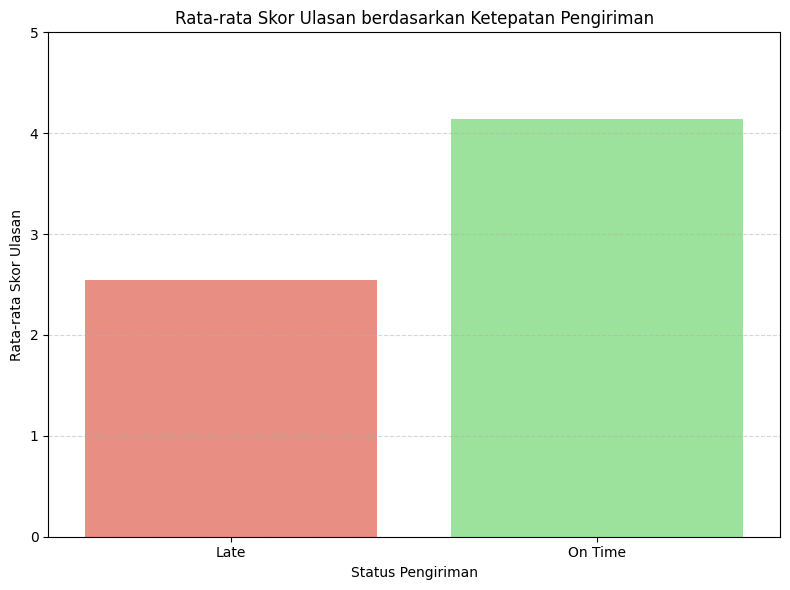

Rata-rata skor ulasan berdasarkan status pengiriman:
  delivery_status  review_score
0            Late      2.548884
1         On Time      4.137190


In [92]:
# Merge dataframe
delivery_review_product_df_overall = orders_df.merge(order_reviews_df, on='order_id', how='left') \
                                           .merge(order_items_df, on='order_id', how='left') \
                                           .merge(translated_products_df, on='product_id', how='left')

# Hitung Ketepatan Pengiriman
delivery_review_product_df_overall['delivery_status'] = (
    delivery_review_product_df_overall['order_delivered_customer_date'] <= delivery_review_product_df_overall['order_estimated_delivery_date']
).apply(lambda x: 'On Time' if x else 'Late')

# Hitung rata-rata skor ulasan berdasarkan status pengiriman
average_review_score_by_delivery_status = delivery_review_product_df_overall.groupby('delivery_status')['review_score'].mean().reset_index()

# Visualisasi
plt.figure(figsize=(8, 6))
sns.barplot(x='delivery_status', y='review_score', data=average_review_score_by_delivery_status, palette=['salmon', 'lightgreen'], hue='delivery_status', legend=False)
plt.title('Rata-rata Skor Ulasan berdasarkan Ketepatan Pengiriman')
plt.xlabel('Status Pengiriman')
plt.ylabel('Rata-rata Skor Ulasan')
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Rata-rata skor ulasan berdasarkan status pengiriman:")
print(average_review_score_by_delivery_status)

In [93]:
main_df = orders_df.merge(customer_df, on='customer_id', how='left') \
           .merge(order_reviews_df, on='order_id', how='left') \
           .merge(order_items_df, on='order_id', how='left') \
           .merge(translated_products_df, on='product_id', how='left') \
           .merge(sellers_df, on='seller_id', how='left') \
           .merge(order_payments_df, on='order_id', how='left')

display(main_df.head())

print("\nInformasi main_df:")
main_df.info()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_time,processing_time,...,product_width_cm,product_category_name,volume,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2,...,13.0,housewares,1976.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2,...,13.0,housewares,1976.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2,...,13.0,housewares,1976.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,0,...,19.0,perfumery,4693.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,0,...,21.0,auto,9576.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12



Informasi main_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              119143 non-null  datetime64[ns]
 5   order_delivered_carrier_date   119143 non-null  datetime64[ns]
 6   order_delivered_customer_date  119143 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   approval_time                  119143 non-null  float64       
 9   processing_time                119143 non-null  int64         
 10  shipping_time                  119143 non-null  

In [94]:
main_df.to_csv('main_df.csv', index=False)

## Analisis Lanjutan (Geospasial Analysis)

In [96]:
# Hitung centroid koordinat kota
center_lat = geospatial_revenue['geolocation_lat'].mean()
center_lng = geospatial_revenue['geolocation_lng'].mean()

#Buat base map
m = folium.Map(location=[center_lat, center_lng], zoom_start=4)

# Membuat colormap berdsarkan revenue
min_revenue = geospatial_revenue['total_revenue'].min()
max_revenue = geospatial_revenue['total_revenue'].max()
colormap = cm.linear.Blues_09.scale(min_revenue, max_revenue)

#Menambahkan titik pada base map
for idx, row in geospatial_revenue.iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=row['total_revenue'] / geospatial_revenue['total_revenue'].max() * 20 + 5, # Scale radius for better visibility
        color='Blue',
        fill=True,
        fill_color=colormap(row['total_revenue']),
        fill_opacity=0.8,
        tooltip=f"{row['city']}: {row['total_revenue']:.2f} BRL"
    ).add_to(m)

# Add the colormap legend to the map
colormap.caption = 'Total Revenue (BRL)'
m.add_child(colormap)

# Display the map
m

NameError: name 'geospatial_revenue' is not defined

## Conclusion

- Conclution pertanyaan 1

  **1). 10 Kategori Produk dengan Rata-rata Skor Ulasan Tertinggi:**
   *   Kategori seperti `cds_dvds_musicals`, `fashion_childrens_clothes`, dan `books_general_interest` memiliki rata-rata skor ulasan tertinggi (mendekati atau di atas 4.4 dari skala 5). Ini menunjukkan kepuasan pelanggan yang sangat tinggi terhadap produk-produk di kategori ini. Kategori-kategori ini dapat menjadi fokus untuk strategi retensi pelanggan atau cross-selling.

  **2). 10 Kategori Produk dengan Rata-rata Skor Ulasan Terendah:**
   *   Sebaliknya, kategori seperti `security_and_services`, `diapers_and_hygiene`, `office_furniture`, dan `home_comfort_2` menunjukkan rata-rata skor ulasan terendah (mulai dari 2.5 hingga sekitar 3.6). Ini adalah kategori-kategori yang memerlukan perhatian khusus.
   *   Terutama, `security_and_services` memiliki skor terendah secara signifikan (2.5). Hal ini sangat mengkhawatirkan dan memerlukan investigasi mendalam mengenai penyebab ketidakpuasan pelanggan di kategori ini. Apakah ada masalah dengan kualitas produk, pengiriman, deskripsi yang tidak akurat, atau aspek layanan lainnya?

- Conclution pertanyaan 2:

  - Pelanggan yang mengalami pengiriman terlambat (*Late*) memberikan rata-rata skor ulasan yang jauh lebih rendah (sekitar 2,5 poin) dibandingkan dengan mereka yang menerima pengiriman tepat waktu (*On Time*) (sekitar 4,2 poin).
  - Perbedaan skor yang mencolok ini menunjukkan bahwa ketepatan waktu pengiriman adalah salah satu faktor penentu utama yang memengaruhi persepsi dan kepuasan pelanggan secara keseluruhan. Kegagalan dalam pengiriman tepat waktu hampir dipastikan akan menyebabkan rating yang buruk.